In [15]:

# --- Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
# --- Load Dataset ---
df = pd.read_csv('../data/ipl_player_stats.csv')
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1172, 25)


,Year,Player_Name,Matches_Batted,Not_Outs,Runs_Scored,Highest_Score,Batting_Average,Balls_Faced,Batting_Strike_Rate,Centuries,...,Matches_Bowled,Balls_Bowled,Runs_Conceded,Wickets_Taken,Best_Bowling_Match,Bowling_Average,Economy_Rate,Bowling_Strike_Rate,Four_Wicket_Hauls,Five_Wicket_Hauls
0,2024,Ruturaj Gaikwad,2,0,61,46,30.5,51,119.61,0,...,2,0,0,0,0,0,0,0,0,0
1,2023,Ruturaj Gaikwad,16,1,590,92,42.14,400,147.5,0,...,16,0,0,0,0,0,0,0,0,0
2,2022,Ruturaj Gaikwad,14,0,368,99,26.29,291,126.46,0,...,14,0,0,0,0,0,0,0,0,0
3,2021,Ruturaj Gaikwad,16,2,635,101*,45.35,466,136.26,1,...,16,0,0,0,0,0,0,0,0,0
4,2020,Ruturaj Gaikwad,6,2,204,72,51,169,120.71,0,...,6,0,0,0,0,0,0,0,0,0


In [17]:
# --- Explore the Data ---
print("Columns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Columns: ['Year', 'Player_Name', 'Matches_Batted', 'Not_Outs', 'Runs_Scored', 'Highest_Score', 'Batting_Average', 'Balls_Faced', 'Batting_Strike_Rate', 'Centuries', 'Half_Centuries', 'Fours', 'Sixes', 'Catches_Taken', 'Stumpings', 'Matches_Bowled', 'Balls_Bowled', 'Runs_Conceded', 'Wickets_Taken', 'Best_Bowling_Match', 'Bowling_Average', 'Economy_Rate', 'Bowling_Strike_Rate', 'Four_Wicket_Hauls', 'Five_Wicket_Hauls']

Data Types:
 Year                   object
Player_Name            object
Matches_Batted         object
Not_Outs               object
Runs_Scored            object
Highest_Score          object
Batting_Average        object
Balls_Faced            object
Batting_Strike_Rate    object
Centuries              object
Half_Centuries         object
Fours                  object
Sixes                  object
Catches_Taken          object
Stumpings              object
Matches_Bowled         object
Balls_Bowled           object
Runs_Conceded          object
Wickets_Taken          ob

In [18]:
# --- Select Numerical Features for Matrix ---
# These are the player performance stats we care about
# --- Select Numerical Features for Matrix ---
features = [
    'Matches_Batted',       # Matches played
    'Runs_Scored',          # Total runs scored
    'Batting_Average',      # Batting average
    'Batting_Strike_Rate',  # Strike rate
    'Wickets_Taken',        # Wickets taken
    'Economy_Rate',         # Economy rate
    'Bowling_Average',      # Bowling average
    'Centuries',            # 100s scored
    'Half_Centuries',       # 50s scored
    'Catches_Taken'         # Fielding
]

# Fix the player column name too!
df_clean = df[['Player_Name'] + features].dropna()
print(f"Players after cleaning: {len(df_clean)}")
df_clean.head()

Players after cleaning: 1172


,Player_Name,Matches_Batted,Runs_Scored,Batting_Average,Batting_Strike_Rate,Wickets_Taken,Economy_Rate,Bowling_Average,Centuries,Half_Centuries,Catches_Taken
0,Ruturaj Gaikwad,2,61,30.5,119.61,0,0,0,0,0,0
1,Ruturaj Gaikwad,16,590,42.14,147.5,0,0,0,0,4,17
2,Ruturaj Gaikwad,14,368,26.29,126.46,0,0,0,0,3,4
3,Ruturaj Gaikwad,16,635,45.35,136.26,0,0,0,1,4,6
4,Ruturaj Gaikwad,6,204,51,120.71,0,0,0,0,3,4


In [19]:
# --- Build the Player x Stats Matrix A ---

# Replace 'No stats' (and any other non-numeric strings) with NaN
df_clean[features] = df_clean[features].replace('No stats', np.nan)

# Drop rows that still have NaN after replacement
df_clean = df_clean.dropna(subset=features)


A = df_clean[features].values.astype(float)

print("Matrix A Shape:", A.shape)
print(f"  → {A.shape[0]} players (rows)")
print(f"  → {A.shape[1]} features/stats (columns)")
print("\nMatrix A (first 5 rows):\n", A[:5])

Matrix A Shape: (1130, 10)
  → 1130 players (rows)
  → 10 features/stats (columns)

Matrix A (first 5 rows):
 [[  2.    61.    30.5  119.61   0.     0.     0.     0.     0.     0.  ]
 [ 16.   590.    42.14 147.5    0.     0.     0.     0.     4.    17.  ]
 [ 14.   368.    26.29 126.46   0.     0.     0.     0.     3.     4.  ]
 [ 16.   635.    45.35 136.26   0.     0.     0.     1.     4.     6.  ]
 [  6.   204.    51.   120.71   0.     0.     0.     0.     3.     4.  ]]


In [20]:
# --- Interpret as a Linear Transformation ---
# Matrix A maps each player (vector in R^7) to a point
# in performance space. Each row is a player vector.
# Each column is a feature dimension.

player_names = df_clean['Player_Name'].values

print("Sample Player Vectors:")
for i in range(3):
    print(f"\n{player_names[i]}:")
    for j, feat in enumerate(features):
        print(f"  {feat}: {A[i][j]}")

Sample Player Vectors:

Ruturaj Gaikwad:
  Matches_Batted: 2.0
  Runs_Scored: 61.0
  Batting_Average: 30.5
  Batting_Strike_Rate: 119.61
  Wickets_Taken: 0.0
  Economy_Rate: 0.0
  Bowling_Average: 0.0
  Centuries: 0.0
  Half_Centuries: 0.0
  Catches_Taken: 0.0

Ruturaj Gaikwad:
  Matches_Batted: 16.0
  Runs_Scored: 590.0
  Batting_Average: 42.14
  Batting_Strike_Rate: 147.5
  Wickets_Taken: 0.0
  Economy_Rate: 0.0
  Bowling_Average: 0.0
  Centuries: 0.0
  Half_Centuries: 4.0
  Catches_Taken: 17.0

Ruturaj Gaikwad:
  Matches_Batted: 14.0
  Runs_Scored: 368.0
  Batting_Average: 26.29
  Batting_Strike_Rate: 126.46
  Wickets_Taken: 0.0
  Economy_Rate: 0.0
  Bowling_Average: 0.0
  Centuries: 0.0
  Half_Centuries: 3.0
  Catches_Taken: 4.0


In [21]:
# --- Normalize the Matrix (Mean Centering) ---
# We subtract the mean of each column so all features
# are on a comparable scale — important for later steps

A_mean = np.mean(A, axis=0)
A_centered = A - A_mean

print("Column Means (per feature):")
for feat, mean in zip(features, A_mean):
    print(f"  {feat}: {mean:.2f}")

print("\nCentered Matrix A (first 3 rows):\n", A_centered[:3])

Column Means (per feature):
  Matches_Batted: 9.02
  Runs_Scored: 132.25
  Batting_Average: 17.44
  Batting_Strike_Rate: 102.31
  Wickets_Taken: 4.46
  Economy_Rate: 5.47
  Bowling_Average: 18.57
  Centuries: 0.04
  Half_Centuries: 0.74
  Catches_Taken: 3.30

Centered Matrix A (first 3 rows):
 [[-7.01681416e+00 -7.12530973e+01  1.30572389e+01  1.72950088e+01
  -4.45929204e+00 -5.47109735e+00 -1.85724425e+01 -4.24778761e-02
  -7.35398230e-01 -3.30442478e+00]
 [ 6.98318584e+00  4.57746903e+02  2.46972389e+01  4.51850088e+01
  -4.45929204e+00 -5.47109735e+00 -1.85724425e+01 -4.24778761e-02
   3.26460177e+00  1.36955752e+01]
 [ 4.98318584e+00  2.35746903e+02  8.84723894e+00  2.41450088e+01
  -4.45929204e+00 -5.47109735e+00 -1.85724425e+01 -4.24778761e-02
   2.26460177e+00  6.95575221e-01]]


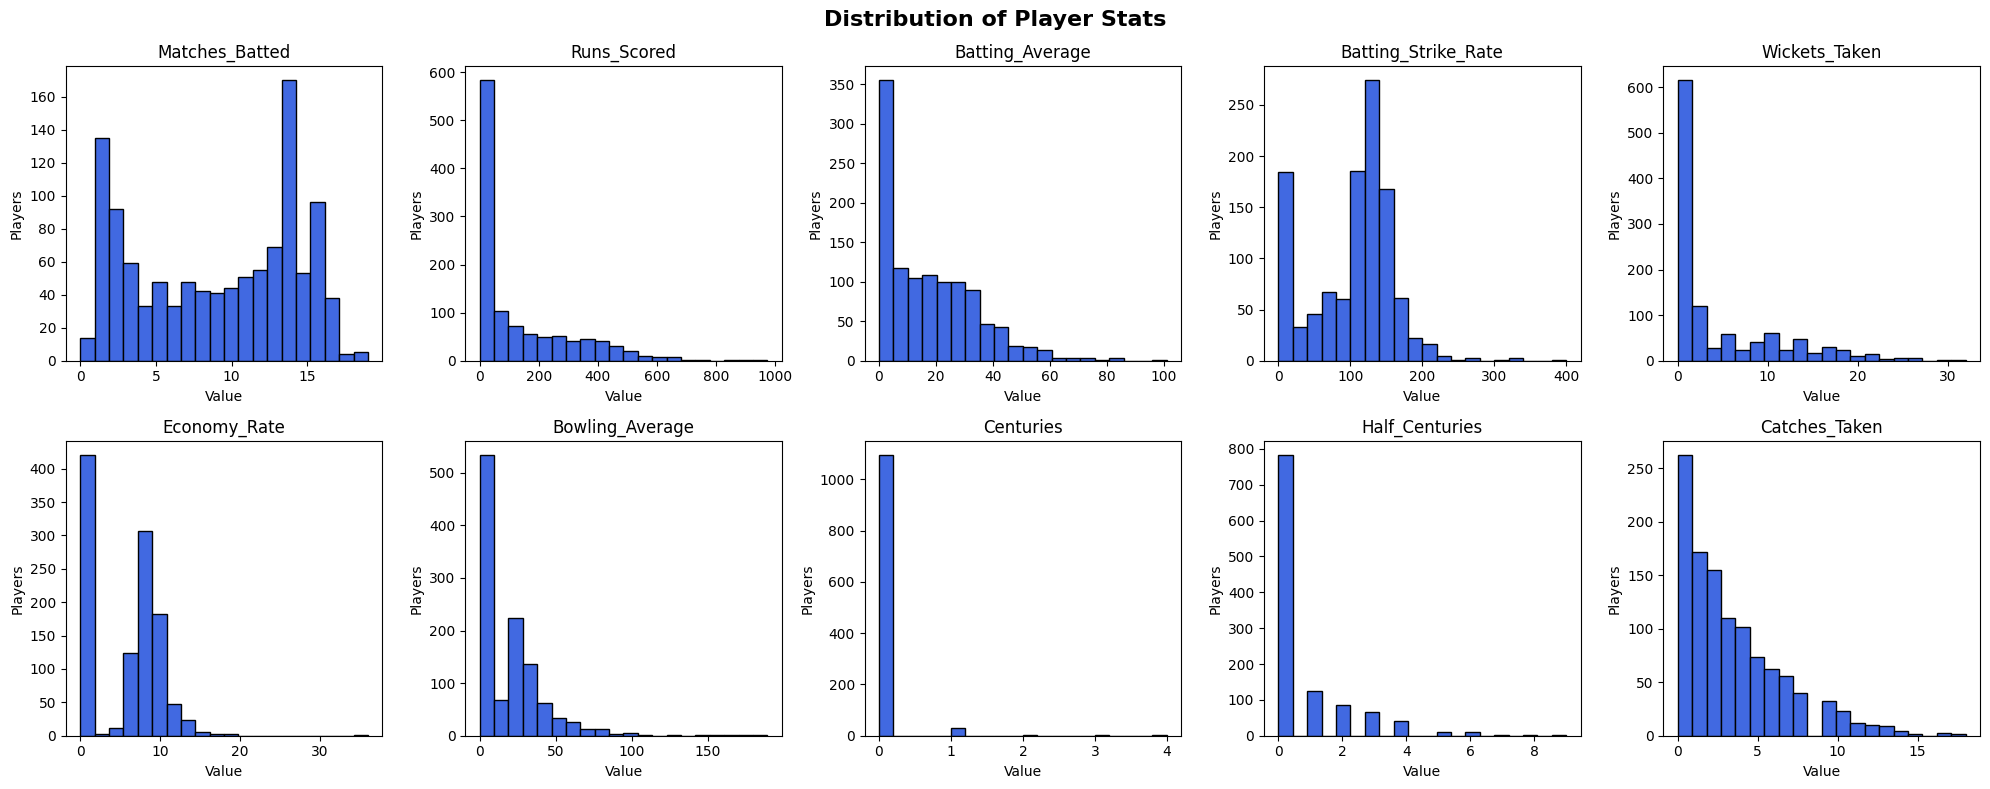

In [24]:
# --- Visualize the Raw Stats ---
fig, axes = plt.subplots(2, 5, figsize=(20, 8))  # 2x5 = 10 slots for 10 features
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].hist(A[:, i], bins=20, color='royalblue', edgecolor='black')
    axes[i].set_title(feat)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Players')

plt.suptitle('Distribution of Player Stats', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/step1_stats_distribution.png', dpi=150)
plt.show()

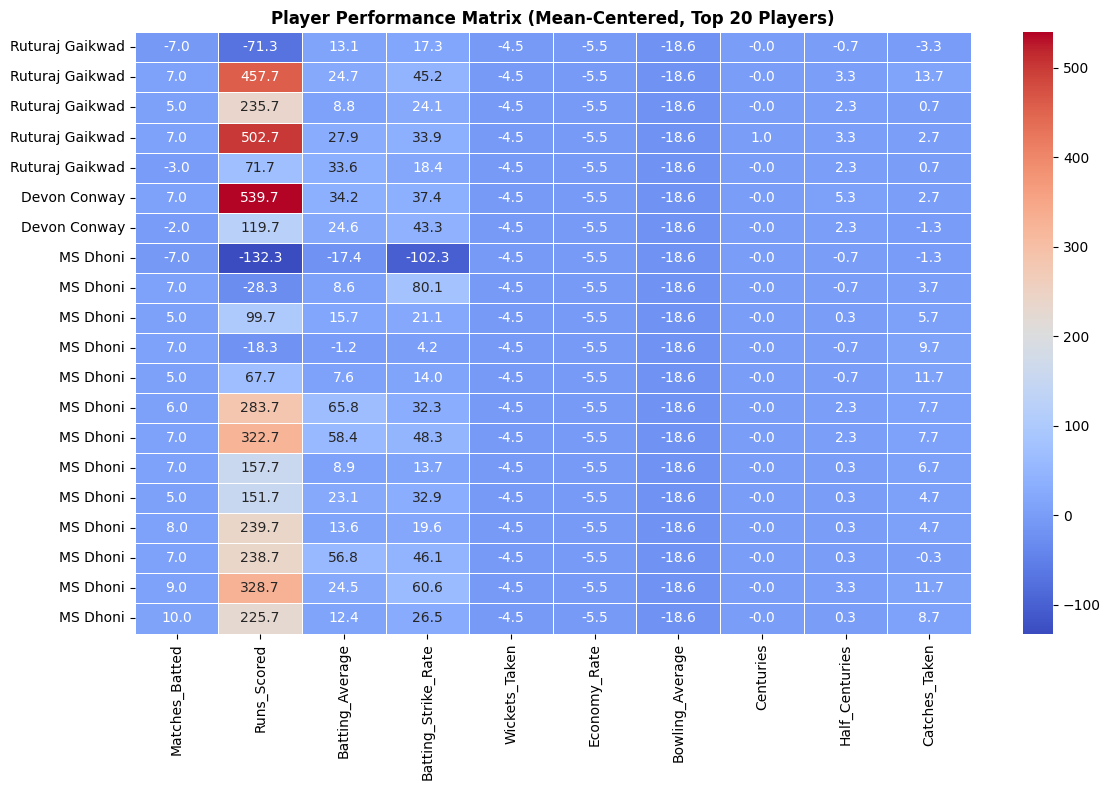

In [25]:
# --- Heatmap of the Matrix ---
plt.figure(figsize=(12, 8))
sns.heatmap(
    pd.DataFrame(A_centered[:20], columns=features, index=player_names[:20]),
    annot=True, fmt='.1f', cmap='coolwarm', linewidths=0.5
)
plt.title('Player Performance Matrix (Mean-Centered, Top 20 Players)', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/step1_matrix_heatmap.png', dpi=150)
plt.show()

In [26]:
# --- Save Matrix for Next Steps ---
np.save('../data/A_matrix.npy', A)
np.save('../data/A_centered.npy', A_centered)
np.save('../data/A_mean.npy', A_mean)
pd.Series(player_names).to_csv('../data/player_names.csv', index=False)
pd.Series(features).to_csv('../data/features.csv', index=False)

print("✅ Matrix saved successfully!")
print("   → data/A_matrix.npy")
print("   → data/A_centered.npy")
print("   → Ready for Step 2: Matrix Simplification")

✅ Matrix saved successfully!
   → data/A_matrix.npy
   → data/A_centered.npy
   → Ready for Step 2: Matrix Simplification
